In [1]:
import pandas as pd
import re

result_df = pd.read_csv("results.csv")
activities = pd.read_excel("realdata_v5_2_new.xlsx", sheet_name="ActivitiesInfo")
classrooms = pd.read_excel("realdata_v5_2_new.xlsx", sheet_name="ClassroomsInfo")
student_df = pd.read_excel("realdata_v5_2_new.xlsx", sheet_name="StudentsInfo")


In [2]:


def parse_result(s):
    if pd.isna(s) or s == "":
        return []
    
    pattern = re.compile(r"\{(\d+):(\d+)\}")
    matches = pattern.findall(str(s))

    return [
        {"subject": int(subject), "room": int(room)}
        for subject, room in matches
    ]

result_df["result"] = result_df["result"].apply(parse_result)


print(result_df["result"].head(5))

0    [{'subject': 11, 'room': 4}, {'subject': 11, '...
1    [{'subject': 5, 'room': 11}, {'subject': 16, '...
2                        [{'subject': 35, 'room': 55}]
3    [{'subject': 53, 'room': 8}, {'subject': 53, '...
4                        [{'subject': 35, 'room': 15}]
Name: result, dtype: object


In [3]:

result_expanded = result_df.explode("result").reset_index(drop=True)
result_expanded = pd.concat([
    result_expanded.drop("result", axis=1),
    result_expanded["result"].apply(pd.Series)
], axis=1)


merged_data = pd.merge(
    result_expanded,
    activities,
    left_on="subject",
    right_on="Course_ID",
    how="left"
)


merged_data = pd.merge(
    merged_data,
    classrooms,
    left_on="room",
    right_on="Classroom_ID",
    how="left",
    suffixes=("_activity", "_classroom")
)



In [14]:
# Expand the dictionary list in the "result" column
result_expanded = result_df.explode("result").reset_index(drop=True)
result_expanded = pd.concat([
    result_expanded.drop("result", axis=1),
    result_expanded["result"].apply(pd.Series)
], axis=1)


# Check for duplicates in activities and classrooms
activities = activities.drop_duplicates(subset=["Course_ID"])
classrooms = classrooms.drop_duplicates(subset=["Classroom_ID"])

# Merge with activities
merged_data = pd.merge(
    result_expanded,
    activities,
    left_on="subject",
    right_on="Course_ID",
    how="left"
)

# Merge with classrooms
merged_data = pd.merge(
    merged_data,
    classrooms,
    left_on="room",
    right_on="Classroom_ID",
    how="left",
    suffixes=("_activity", "_classroom")
)

# Check the final merged data
print(merged_data.head())
print(merged_data.shape)  # Verify the number of rows

   Week  Time_slot subject_candidates  value  subject  room  \
0     1          1            {11,13}    3.0       11     4   
1     1          1            {11,13}    3.0       11    58   
2     1          1            {11,13}    3.0       13    32   
3     1          2       {5,16,18,40}   11.0        5    11   
4     1          2       {5,16,18,40}   11.0       16    15   

                      Course_Name Course_Code  Course_ID  \
0  Honours Differential Equations   MATH10066         11   
1  Honours Differential Equations   MATH10066         11   
2  Combinatorics and Graph Theory   MATH10072         13   
3            Mathematical Biology   MATH10013          5   
4         Statistical Methodology   MATH10095         16   

                                     Activity  ... Classroom_ID  Is_Isolated  \
0  MATH3 Honours Diff Equations - Workshop/01  ...          4.0          0.0   
1  MATH3 Honours Diff Equations - Workshop/01  ...         58.0          0.0   
2     MATH3 Comb & G

In [18]:

# Expand the dictionary list in the "result" column
# separate the courses column

student_df["CourseID"] = student_df["Course_ID"].str.split(', ')
students = student_df.explode("CourseID")

# Calculate the number of students for each course
student_count = students.groupby("CourseID")["Student_ID"].nunique()

# Merge the student count with the merged data
merged_data["subject"] = merged_data["subject"].astype(str)
merged_data = pd.merge(
    merged_data,
    student_count,
    left_on="subject",
    right_on="CourseID",
    how="left"
)


In [19]:
# 标记虚拟教室
merged_data["is_virtual"] = (merged_data["room"] == 0)

# 计算教室容量利用率
merged_data['Utilization'] = merged_data['New_Num'] / merged_data['Capacity']
print(merged_data['Utilization'].head(5))



0    0.019169
1    0.016043
2    0.071066
3    0.682051
4    5.416667
Name: Utilization, dtype: float64


In [54]:
import pandas as pd
import numpy as np

# Calculate real utilization, aggregated by week and time slot

merged_data['weekly_capacity'] = merged_data.groupby(["Week", "Time_slot","Course_ID"])["Capacity"].transform('sum')
merged_data['weekly_student_count'] = merged_data.groupby(["Week", "Time_slot","Course_ID"])["Student_ID"].transform('mean')
calculated_data = merged_data[["Week", "Time_slot","Course_ID","weekly_capacity", "weekly_student_count", "real_utilization"]].copy()

calculated_data = calculated_data.drop_duplicates().reset_index(drop=True)

calculated_data["real_utilization"] = calculated_data["weekly_student_count"] / calculated_data['weekly_capacity']

calculated_data

,Week,Time_slot,Course_ID,weekly_capacity,weekly_student_count,real_utilization
0,1,1,11,687.0,74.0,0.107715
1,1,1,13,197.0,91.0,0.461929
2,1,2,5,195.0,133.0,0.682051
3,1,2,16,754.0,195.0,0.258621
4,1,2,18,135.0,69.0,0.511111
...,...,...,...,...,...,...
129,12,1,2,412.0,88.0,0.213592
130,12,2,33,230.0,71.0,0.308696
131,12,3,27,400.0,17.0,0.042500
132,12,7,30,595.0,159.0,0.267227


In [64]:

# Check for inf values
print("Inf values:", calculated_data[np.isinf(calculated_data["real_utilization"])])
# Replace inf values with NaN
calculated_data["real_utilization"] = calculated_data["real_utilization"].replace([np.inf, -np.inf], np.nan)
# Fill NaN values with a default value (e.g., 0)
calculated_data["real_utilization"] = calculated_data["real_utilization"].fillna(0)
# Filter out outliers
calculated_data = calculated_data[(calculated_data["real_utilization"] > 0) & (calculated_data["real_utilization"] < 1)]   
print("Value distribution:", calculated_data["real_utilization"].describe())

# Calculate the mean
mean_utilization = calculated_data["real_utilization"].mean()
print("Mean utilization:", mean_utilization)
calculated_data

Inf values: Empty DataFrame
Columns: [Week, Time_slot, Course_ID, weekly_capacity, weekly_student_count, real_utilization]
Index: []
Value distribution: count    117.000000
mean       0.347105
std        0.211053
min        0.042500
25%        0.186813
50%        0.280000
75%        0.433333
max        0.986111
Name: real_utilization, dtype: float64
Mean utilization: 0.34710549285032954


,Week,Time_slot,Course_ID,weekly_capacity,weekly_student_count,real_utilization
0,1,1,11,687.0,74.0,0.107715
1,1,1,13,197.0,91.0,0.461929
2,1,2,5,195.0,133.0,0.682051
3,1,2,16,754.0,195.0,0.258621
4,1,2,18,135.0,69.0,0.511111
...,...,...,...,...,...,...
129,12,1,2,412.0,88.0,0.213592
130,12,2,33,230.0,71.0,0.308696
131,12,3,27,400.0,17.0,0.042500
132,12,7,30,595.0,159.0,0.267227


In [65]:
# Proportion of virtual classrooms
virtual_ratio = merged_data["is_virtual"].mean()
print(f"Proportion of virtual classrooms: {virtual_ratio:.1%}")

# Distribution of real classroom utilization
utilization_stats = merged_data[~merged_data["is_virtual"]]["real_utilization"].describe()
print("\nDistribution of real classroom utilization:")
print(utilization_stats.to_markdown())

# High-frequency conflict subjects
conflict_subjects = merged_data.groupby("Course_Name").size().sort_values(ascending=False).head(5)
print("\nHigh-frequency conflict subjects:")
print(conflict_subjects.to_markdown())

虚拟教室占比: 1.8%

实际教室利用率分布:
|       |   real_utilization |
|:------|-------------------:|
| count |         271        |
| mean  |           0.961065 |
| std   |           0.756177 |
| min   |           0.0425   |
| 25%   |           0.466558 |
| 50%   |           0.841603 |
| 75%   |           1.22899  |
| max   |           8.05     |

高频冲突科目:
| Course_Name                                           |   0 |
|:------------------------------------------------------|----:|
| Honours Differential Equations                        |  18 |
| Statistical Methodology                               |  18 |
| Fundamentals of Operational Research                  |  17 |
| Probability, Measure & Finance, Discrete-Time Finance |  16 |
| Further Complex Variables                             |  15 |


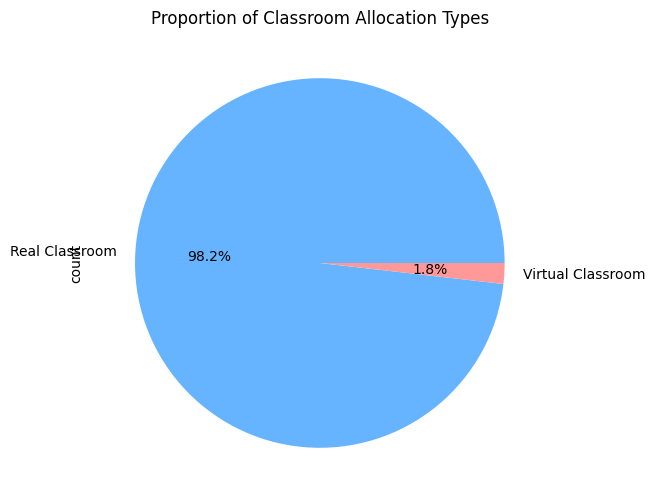

In [66]:
import matplotlib.pyplot as plt
#虚拟与实际教室分配对比图
plt.figure(figsize=(8, 6))
merged_data["is_virtual"].value_counts().plot.pie(
    labels=["Real Classroom", "Virtual Classroom"],
    autopct="%1.1f%%",
    colors=["#66b3ff", "#ff9999"]
)
plt.title("Proportion of Classroom Allocation Types")
plt.savefig("virtual_vs_real.png", dpi=300, bbox_inches="tight")


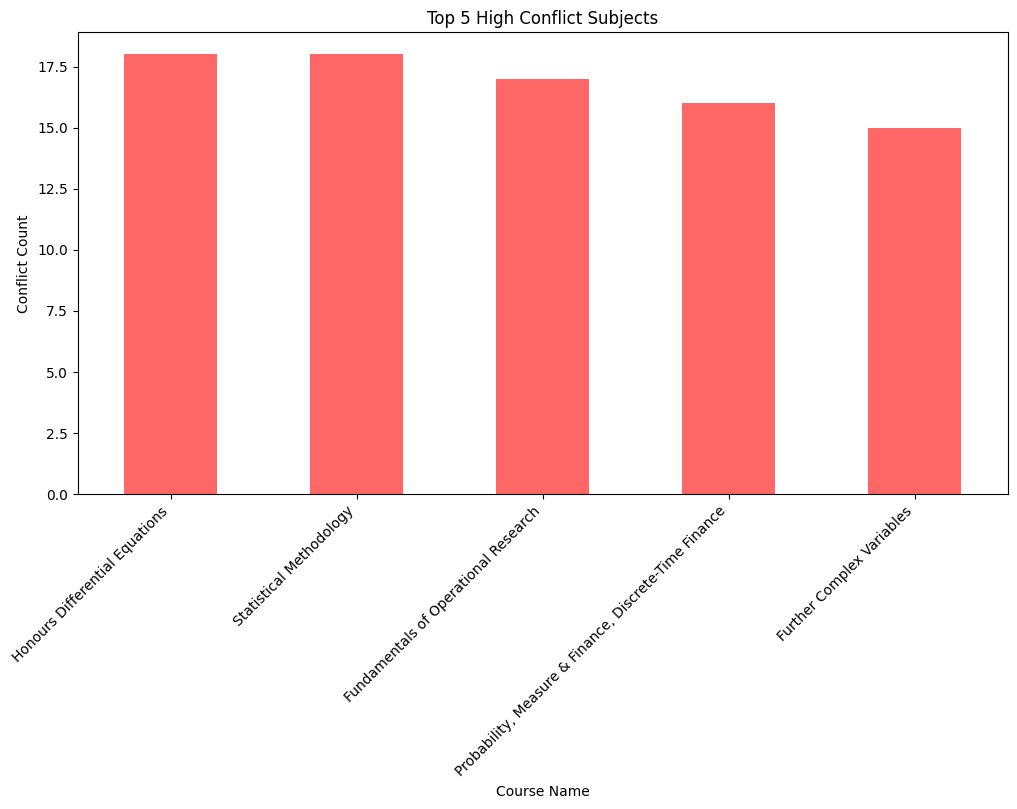

In [67]:
# Distribution of High-Frequency Conflict Subjects
plt.figure(figsize=(12, 6))
conflict_subjects.plot.bar(color="#ff6666")
plt.title("Top 5 High-Frequency Conflict Subjects")
plt.xlabel("Course Name")
plt.ylabel("Conflict Count")
plt.xticks(rotation=45, ha="right")
plt.savefig("conflict_subjects.png", dpi=300, bbox_inches="tight")

In [68]:
calculated_data.to_csv("calculated_data.csv", index=False)

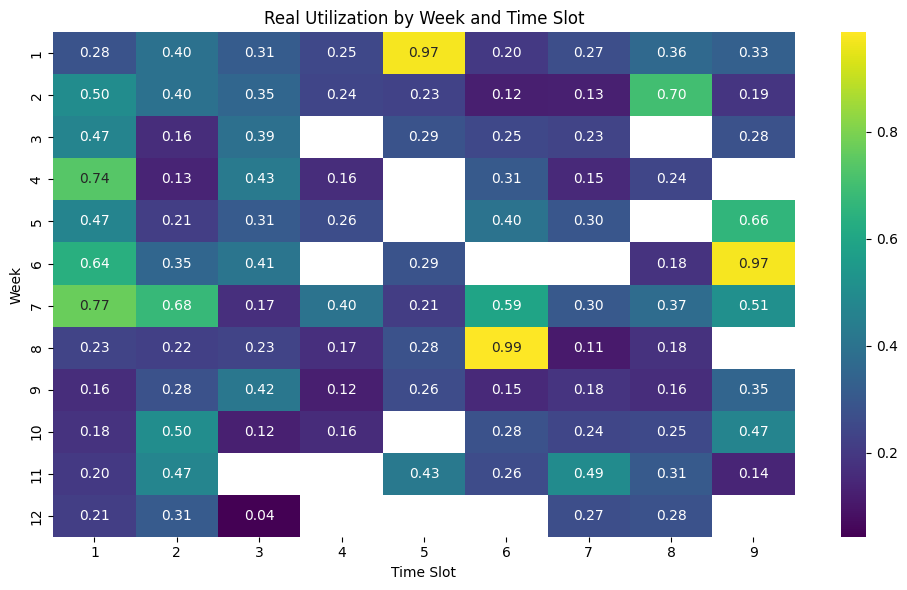

In [69]:

import seaborn as sns
pivot_table = calculated_data.pivot_table(index="Week", columns="Time_slot", values="real_utilization", aggfunc="mean")

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="viridis", fmt=".2f")
plt.xlabel("Time Slot")
plt.ylabel("Week")
plt.title("Real Utilization by Week and Time Slot")
plt.tight_layout()
plt.show()

In [ ]:
# confict matrix
conflict_matrix = merged_data.groupby(["Week", "Time_slot"]).size().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(conflict_matrix, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Week-Time Slot Conflict Heatmap")
plt.xlabel("Time Slot")
plt.ylabel("Week")
plt.savefig("time_conflict_heatmap.png", dpi=300, bbox_inches="tight")

In [ ]:
# 图4: isolated_classroom_usage.png
exam_activities = merged_data[merged_data['Activity_Type_Name'].str.contains('exam')]
isolated_usage = exam_activities['Is_Isolated'].mean()

labels = ['Using Isolated Classroom', 'Not Using Isolated Classroom']
sizes = [isolated_usage, 1 - isolated_usage]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['#99ff99','#ff9999'], 
        wedgeprops={'width':0.4})
plt.title('Usage of Isolated Classrooms for Exam Activities')
plt.savefig('isolated_classroom_usage.png', dpi=300, bbox_inches='tight')



In [ ]:
# merge classroom usage with classroom capacity
classroom_usage_with_capacity = pd.merge(
    classroom_usage,
    classrooms[["Classroom_ID", "Capacity"]],  # 假设 Capacity 列存储教室容量
    left_on="Classroom_ID",
    right_on="Classroom_ID",
    how="left"
)

print(classroom_usage_with_capacity)

In [ ]:
top_n = 25  # Display the top 25 classrooms
classroom_usage = classroom_usage.sort_values(by="Usage_Count", ascending=False)
classroom_usage_top = classroom_usage.head(top_n)

# Merge classroom capacity information
classroom_usage_with_capacity_top = pd.merge(
    classroom_usage_top,
    classrooms[["Classroom_ID", "Capacity"]],
    on="Classroom_ID",
    how="left"
)

# Create the figure and dual axes
fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(classroom_usage_with_capacity_top))

# Plot the usage frequency bar chart (left axis)
ax1.bar(x, classroom_usage_with_capacity_top["Usage_Count"], width=0.4, label="Usage Count", color='skyblue')
ax1.set_xlabel("Classroom ID")
ax1.set_ylabel("Usage Count", color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Create the second y-axis
ax2 = ax1.twinx()

# Plot the classroom capacity bar chart (right axis)
ax2.bar(x + 0.4, classroom_usage_with_capacity_top["Capacity"], width=0.4, label="Capacity", color='orange')
ax2.set_ylabel("Capacity", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Set x-axis labels
plt.xticks(x + 0.2, classroom_usage_with_capacity_top["Classroom_ID"], rotation=45)

# Add title
plt.title("Classroom Usage Count vs Capacity (Top {})".format(top_n))

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

# Add grid lines
plt.grid(axis='y')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
classroom_usage_with_capacity_top["Usage_Count"].mean()
